## 1. Import Library

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Check Dataset

In [17]:
df = pd.read_excel("Copy of Afficionado Coffee Roasters.xlsx")

print(df.columns)

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail'],
      dtype='object')


## 3. Clean Column Names

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail'],
      dtype='object')


## 4. Create Revenue Column

In [4]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]

print(df.head())

   transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025         07:06:11                2         5   
1               2  2025         07:08:56                2         5   
2               3  2025         07:14:04                2         5   
3               4  2025         07:20:24                1         5   
4               5  2025         07:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee   
4  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  revenue  
0  Gourmet brewed coffee                  Ethiopia Rg      6.0  
1        Brewed Chai tea     Spicy Eye Opener 

## 5. Dataset Summary

In [5]:
print("Total Revenue:", df["revenue"].sum())
print("Total Transactions:", df.shape[0])
print("Total Units Sold:", df["transaction_qty"].sum())

Total Revenue: 698812.3300000002
Total Transactions: 149116
Total Units Sold: 214470


## 6. Top Selling Products Analysis

In [6]:
top_products = df.groupby("product_detail")["transaction_qty"].sum().sort_values(ascending=False)

print(top_products.head(10))

product_detail
Earl Grey Rg                   4708
Dark chocolate Lg              4668
Morning Sunrise Chai Rg        4643
Latte                          4602
Peppermint Rg                  4564
Columbian Medium Roast Rg      4547
Traditional Blend Chai Rg      4512
Latte Rg                       4497
Our Old Time Diner Blend Sm    4484
Serenity Green Tea Rg          4477
Name: transaction_qty, dtype: int64


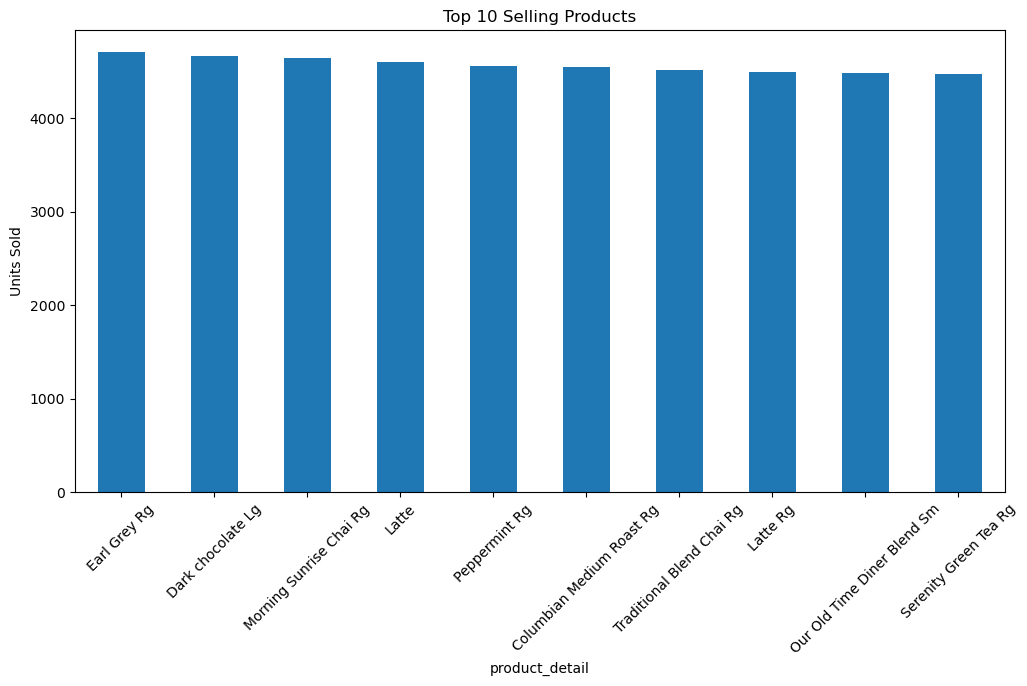

In [7]:
plt.figure(figsize=(12,6))
top_products.head(10).plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

## 7. Top Revenue Products Analysis

In [8]:
top_revenue = df.groupby("product_detail")["revenue"].sum().sort_values(ascending=False)

print(top_revenue.head(10))

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: revenue, dtype: float64


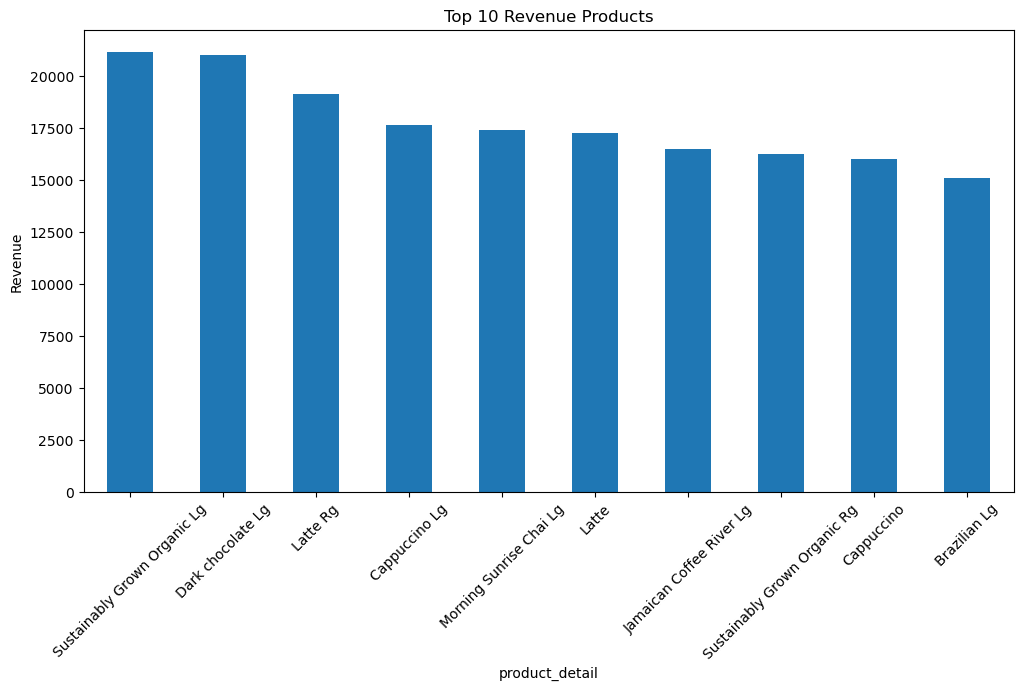

In [9]:
plt.figure(figsize=(12,6))
top_revenue.head(10).plot(kind="bar")
plt.title("Top 10 Revenue Products")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 8. Category Revenue Analysis

In [10]:
category_rev = df.groupby("product_category")["revenue"].sum()

print(category_rev)

product_category
Bakery                 82315.64
Branded                13607.00
Coffee                269952.45
Coffee beans           40085.25
Drinking Chocolate     72416.00
Flavours                8408.80
Loose Tea              11213.60
Packaged Chocolate      4407.64
Tea                   196405.95
Name: revenue, dtype: float64


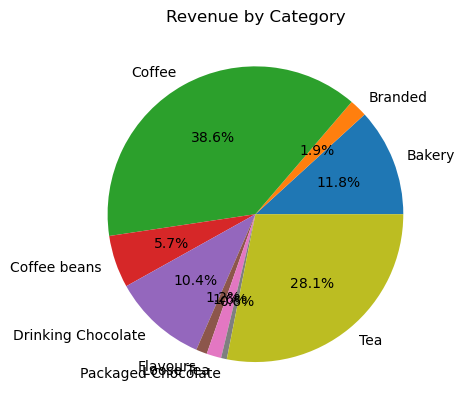

In [11]:
category_rev.plot(kind="pie", autopct='%1.1f%%')
plt.title("Revenue by Category")
plt.ylabel("")
plt.show()

## 9. Popularity vs Revenue Analysis

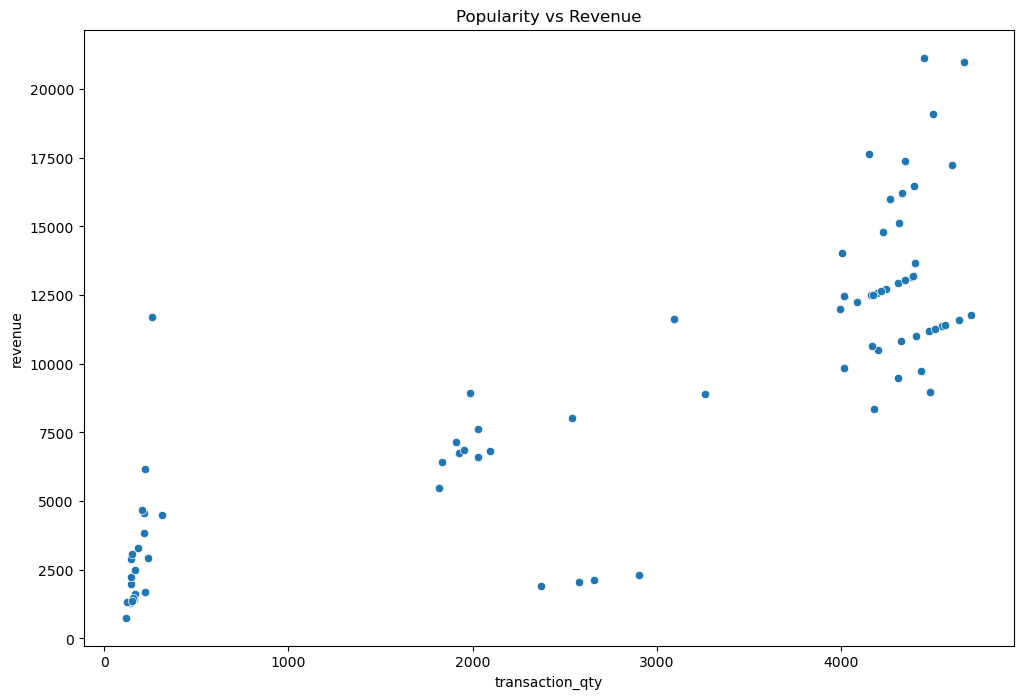

In [12]:
scatter = df.groupby("product_detail").agg({
    "transaction_qty":"sum",
    "revenue":"sum"
}).reset_index()

plt.figure(figsize=(12,8))
sns.scatterplot(data=scatter,
                x="transaction_qty",
                y="revenue")

plt.title("Popularity vs Revenue")
plt.show()

In [13]:
print(df.columns)

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail', 'revenue'],
      dtype='object')


## 10. Pareto Analysis

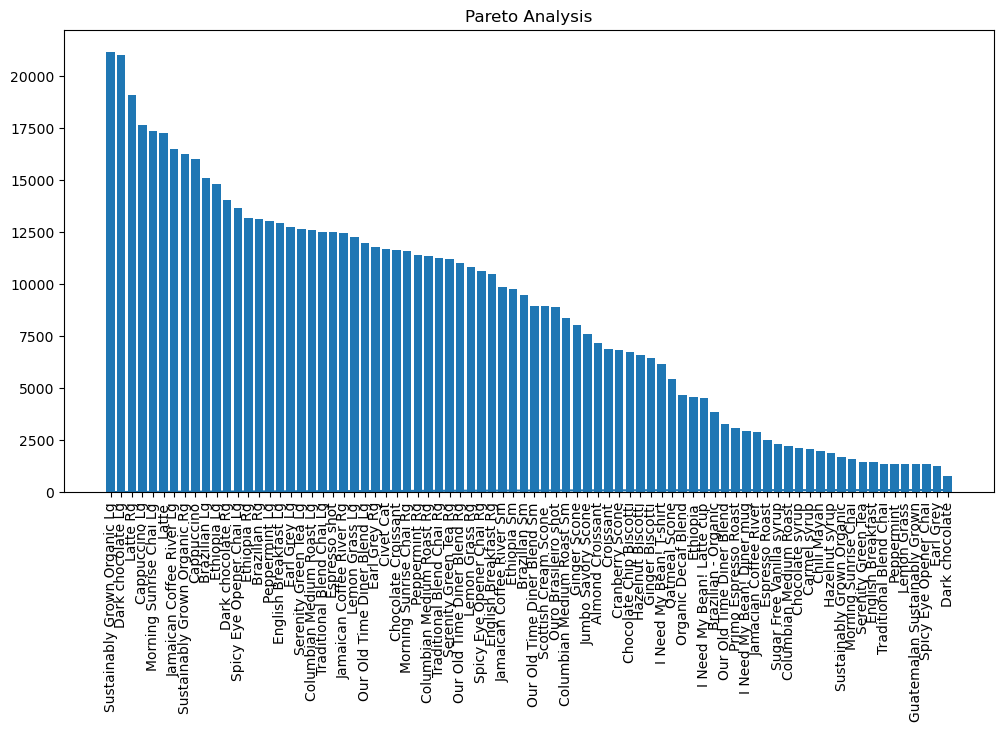

In [18]:
pareto = top_revenue.reset_index()
pareto["cum_perc"] = pareto["revenue"].cumsum()/pareto["revenue"].sum()*100

plt.figure(figsize=(12,6))
plt.bar(pareto["product_detail"], pareto["revenue"])
plt.plot(pareto["cum_perc"])
plt.xticks(rotation=90)
plt.title("Pareto Analysis")
plt.show()


## 11. Least Selling Products Analysis

product_detail
Dark chocolate                  118
Spicy Eye Opener Chai           122
Guatemalan Sustainably Grown    134
Earl Grey                       142
Jamacian Coffee River           146
Columbian Medium Roast          148
Chili Mayan                     148
Primo Espresso Roast            150
Lemon Grass                     152
Traditional Blend Chai          153
Name: transaction_qty, dtype: int64


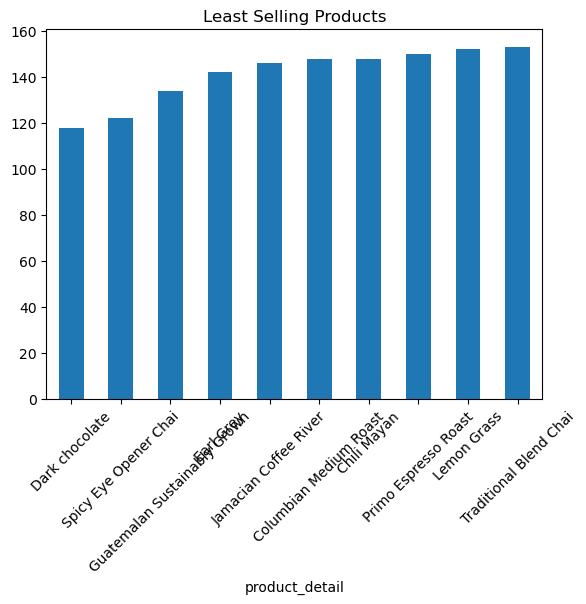

In [23]:
least_products = df.groupby("product_detail")["transaction_qty"].sum().sort_values()

print(least_products.head(10))

least_products.head(10).plot(kind="bar")
plt.title("Least Selling Products")
plt.xticks(rotation=45)
plt.show()

## 12. Store-wise Revenue Analysis

In [31]:
df["revenue"] = df["transaction_qty"]*df["unit_price"]

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64


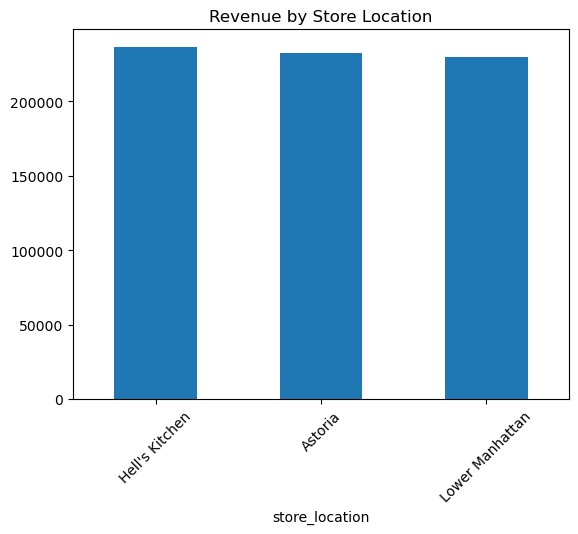

In [32]:
store_rev = df.groupby("store_location")["revenue"].sum().sort_values(ascending=False)

print(store_rev)

store_rev.plot(kind="bar")
plt.title("Revenue by Store Location")
plt.xticks(rotation=45)
plt.show()

## 13. Product Efficiency Score Analysis

In [33]:
efficiency = df.groupby("product_detail").agg({
    "revenue":"sum",
    "transaction_qty":"sum"
})

efficiency["efficiency_score"] = efficiency["revenue"] / efficiency["transaction_qty"]

print(efficiency.sort_values("efficiency_score", ascending=False).head(10))

                           revenue  transaction_qty  efficiency_score
product_detail                                                       
Civet Cat                 11700.00              260         45.000000
I Need My Bean! T-shirt    6163.00              221         27.886878
Organic Decaf Blend        4657.50              206         22.609223
Ethiopia                   4578.00              218         21.000000
Primo Espresso Roast       3067.50              150         20.450000
Jamacian Coffee River      2883.50              146         19.750000
Our Old Time Diner Blend   3294.00              183         18.000000
Brazilian - Organic        3852.00              214         18.000000
Columbian Medium Roast     2220.00              148         15.000000
Espresso Roast             2492.75              169         14.750000


## 14. Conclusion and Recommendations


The analysis of Afficionado Coffee Roasters transaction data provided valuable insights into product-level sales performance and revenue distribution across stores.

Key Findings:
- A limited number of products contribute significantly to total revenue, indicating strong revenue concentration.
- Product popularity and revenue contribution are not always directly related, highlighting the importance of evaluating both metrics.
- Category-wise analysis revealed varying revenue contributions across product groups.
- Store-level revenue performance differs across locations, indicating differences in customer demand patterns.
- Several low-performing products contribute minimally to overall revenue and may require review.

Recommendations:
- Focus promotional strategies on high-performing products to maximize revenue.
- Review low-selling products for redesign, repositioning, or removal from the menu.
- Optimize inventory planning based on high-demand products.
- Use product efficiency metrics for menu optimization and strategic decision-making.

This analysis supports data-driven product optimization and provides actionable insights to improve operational efficiency, menu effectiveness, and long-term profitability for Afficionado Coffee Roasters.